# **Introduction to Machine Learning: Heart Disease Risk Prediction**
### Skill Morph Research Lab
**Instructor:** Md. Samiul Islam

---

## What You will Learn
- What Machine Learning is (in simple words)
- How to load and explore a dataset
- How to train a model to make predictions
- How to check if the model is any good

## Steps We will Follow
1. [What is Machine Learning?](#0)
2. [Import Libraries](#1)
3. [Load the Dataset](#2)
4. [Explore the Data](#3)
5. [Prepare Features & Target](#4)
6. [Split into Training & Testing](#5)
7. [Train the Model](#6)
8. [Make Predictions](#7)
9. [Confusion Matrix](#8)
10. [Performance Scores](#9)
11. [ROC Curve](#10)
12. [Assignment](#11)

---

**Dataset:** [Heart Disease Risk Prediction Dataset (EarlyMed)](https://www.kaggle.com/datasets/mahatiratusher/heart-disease-risk-prediction-dataset) — Kaggle, 2025

**Goal:** Given a patient's symptoms and risk factors → predict if they are at **High Risk** or **Low Risk** of heart disease.

**Dataset at a Glance:** 70,000 patients | 18 features | Binary target (`Heart_Risk`: 0 = Low, 1 = High)

## What is Machine Learning? <a id='0'></a>

**Simple idea:** Instead of writing rules by hand, we show the computer many examples and let it *learn the pattern itself.*

**Analogy:** Imagine a doctor who has seen 70,000 patients. Over time, they learn which combination of symptoms usually means heart disease. Machine Learning does the same thing — but with math.

### Our Plan (3 Steps)
| Step | What Happens |
|------|-------------|
| **1. Train** | Show the model thousands of patient records with known outcomes |
| **2. Predict** | Give the model a *new* patient → it guesses High Risk or Low Risk |
| **3. Evaluate** | Check how many guesses were correct |

### The Algorithm We'll Use: Decision Tree
A Decision Tree asks a series of yes/no questions:
> *Does the patient have chest pain? → Yes → Do they have high blood pressure? → Yes → **High Risk***

It's one of the simplest and most understandable ML algorithms — perfect for learning!

## 1. Import Libraries <a id='1'></a>

We need a few Python libraries. Think of them as toolboxes:
- **pandas** → for loading and working with data tables
- **sklearn** → the Machine Learning toolkit
- **matplotlib / seaborn** → for making charts

In [1]:
# 1. Import Libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_curve, roc_auc_score)
import warnings; warnings.filterwarnings('ignore')
print("✅ All libraries loaded!")

✅ All libraries loaded!


## 2. Load the Dataset <a id='2'></a>

Download from: https://www.kaggle.com/datasets/mahatiratusher/heart-disease-risk-prediction-dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/datasets/heart_disease_risk_dataset_earlymed.csv')


Mounted at /content/drive


In [3]:
data.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


## 3. Explore the Data (EDA) <a id='3'></a>

Before building a model, let's understand what we're working with.

**Key questions:**
- How many rows and columns?
- Any missing data?
- Is the target balanced (roughly equal Low Risk vs High Risk)?

In [7]:
# 3. Explore the Data
print(f"Missing: {data.isnull().sum().sum()}")
print(f"\n Target Distribution:\n{data['Heart_Risk'].value_counts()}")

Missing: 0

 Target Distribution:
Heart_Risk
0.0    35000
1.0    35000
Name: count, dtype: int64


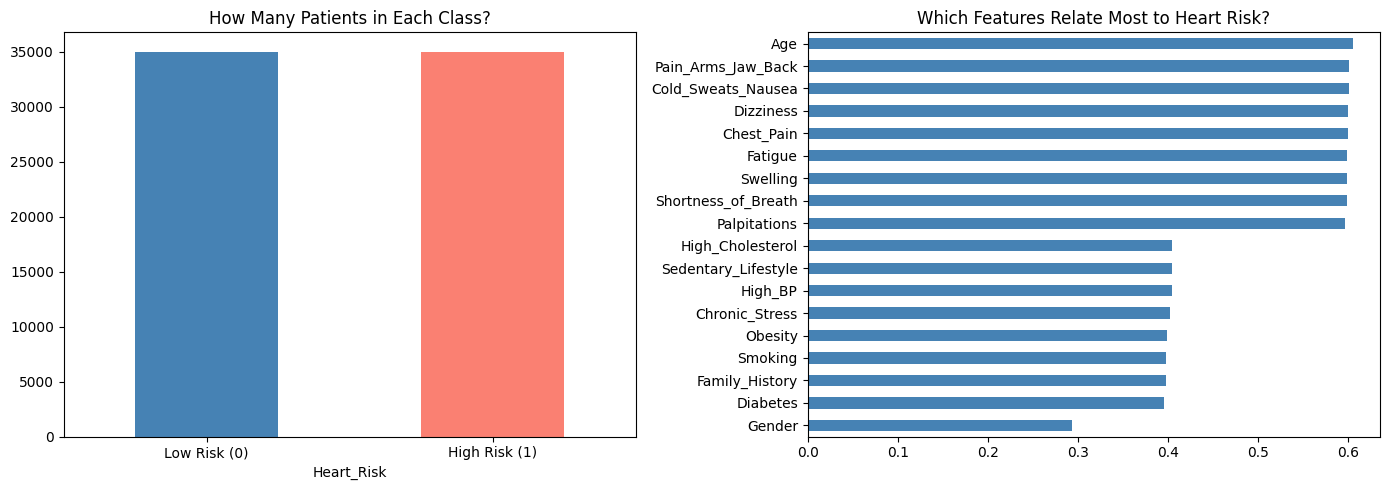

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data['Heart_Risk'].value_counts().plot.bar(ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('How Many Patients in Each Class?')
axes[0].set_xticklabels(['Low Risk (0)', 'High Risk (1)'], rotation=0)

corr = data.corr(numeric_only=True)['Heart_Risk'].drop('Heart_Risk').sort_values()
corr.plot.barh(ax=axes[1], color=['salmon' if v < 0 else 'steelblue' for v in corr])
axes[1].set_title('Which Features Relate Most to Heart Risk?')


plt.tight_layout()
plt.show()

## 4. Prepare Features & Target <a id='4'></a>

We need to separate:
- **X (Features)** → the input information the model will learn from (18 columns)
- **y (Target)** → the answer we want to predict (`Heart_Risk`: 0 or 1)

Good news: all features are already numbers, so no extra conversion needed!

| Category | Features |
|----------|----------|
| **Symptoms (8)** | Chest_Pain, Shortness_of_Breath, Fatigue, Palpitations, Dizziness, Swelling, Pain_Arms_Jaw_Back, Cold_Sweats_Nausea |
| **Risk Factors (8)** | High_BP, High_Cholesterol, Diabetes, Smoking, Obesity, Sedentary_Lifestyle, Family_History, Chronic_Stress |
| **Demographics (2)** | Gender, Age |

In [14]:
# 4. Prepare Features & Target
X = data.drop(columns=['Heart_Risk'])
y = data['Heart_Risk']

## 5. Split into Training & Testing <a id='5'></a>

**Why split?** If we test the model on the *same* data it learned from, it's like giving a student the exam answers beforehand — the score won't be real.

So we split the data:
- **80% → Training set** (the model learns from this)
- **20% → Test set** (we check the model's performance on this — data it has *never seen*)

In [21]:
# 5. Train-Test Split <a id='5'></a>
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
print(f"📚 Training: {X_train.shape} | 🧪 Testing: {X_test.shape}")

📚 Training: (56000, 18) | 🧪 Testing: (14000, 18)


## 6. Train the Model (Decision Tree) <a id='6'></a>

Now the exciting part — we train the model! This means: *"Hey model, look at these 56,000 patients and figure out the pattern."*

`max_depth=5` means the tree can ask up to 5 yes/no questions deep. This prevents the tree from getting too complex.

In [19]:
# 6. Train the Decision Tree
model = DecisionTreeClassifier(max_depth=5, random_state=20)
model.fit(X_train, y_train)
print("✅ Model training complete!")

✅ Model training complete!


## 7. Make Predictions & Check Accuracy <a id='7'></a>

Now we ask the trained model to predict Heart_Risk for the 14,000 test patients it has **never seen before**.

In [20]:
# 7. Predictions & Accuracy
predictions = model.predict(X_test)
prediction_proba = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, predictions)
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

🎯 Accuracy: 0.9420 (94.20%)


## 8. Confusion Matrix <a id='8'></a>

Accuracy alone doesn't tell the full story. The **Confusion Matrix** shows exactly *where* the model made mistakes:

|  | Actual Positive (High Risk) | Actual Negative (Low Risk) |
|--|---|---|
| **Predicted Positive (High Risk)** | ✅ True Positive (TP) | ❌ False Positive (FP) — false alarm |
| **Predicted Negative (Low Risk)** | ❌ False Negative (FN) — missed! | ✅ True Negative (TN) |

**False Negatives are dangerous here** — the model missed a real high-risk patient!

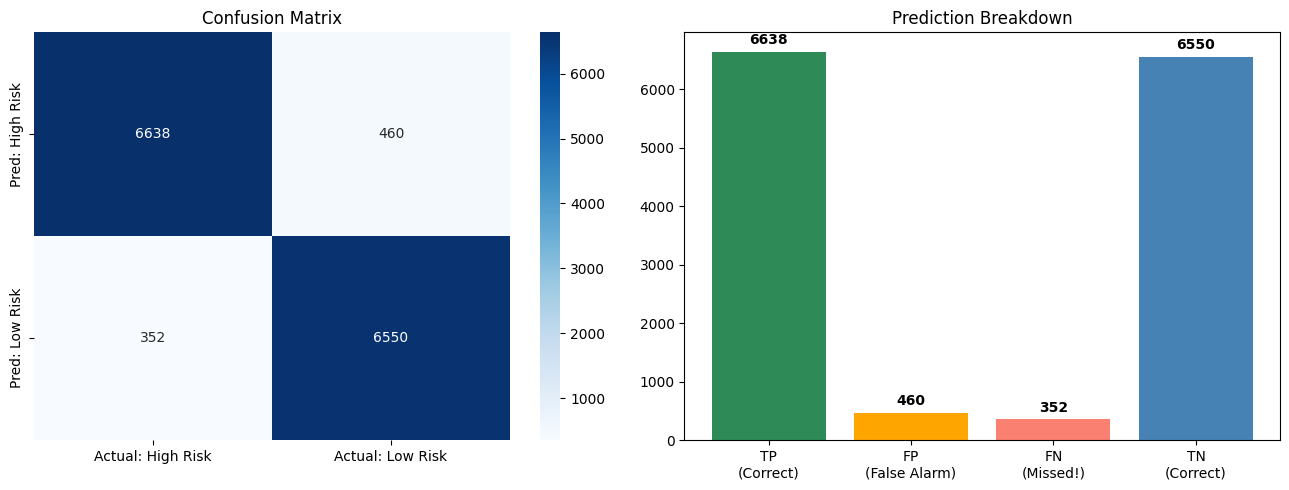

✅ Correct: 13,188 | ❌ Wrong: 812


In [26]:
# 8. Confusion Matrix — Layout: [[TP, FP], [FN, TN]]
cm = confusion_matrix(y_test, predictions, labels=[1, 0]).T  # Transpose for TP top-left, FP top-right

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Actual: High Risk', 'Actual: Low Risk'],
            yticklabels=['Pred: High Risk', 'Pred: Low Risk'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

# Bar chart: TP, FP, FN, TN
TP, FP, FN, TN = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
labels = ['TP\n(Correct)', 'FP\n(False Alarm)', 'FN\n(Missed!)', 'TN\n(Correct)']
vals = [TP, FP, FN, TN]
axes[1].bar(labels, vals, color=['seagreen', 'orange', 'salmon', 'steelblue'])
axes[1].set_title('Prediction Breakdown')
for i, v in enumerate(vals):
    axes[1].text(i, v + max(vals)*0.02, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"✅ Correct: {TP+TN:,} | ❌ Wrong: {FP+FN:,}")

## 9. Performance Scores <a id='9'></a>

Let's look at 4 key metrics:

| Metric | What It Means (Simple) |
|--------|----------------------|
| **Accuracy** | Overall, how often is the model correct? |
| **Precision** | When it says "High Risk", how often is it right? |
| **Recall** | Out of all actual High Risk patients, how many did it catch? |
| **F1-Score** | A balanced mix of Precision and Recall |

In [30]:
# 9. Performance Scores
accuracy  = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall    = recall_score(y_test, predictions)
f1        = f1_score(y_test, predictions)

print(f"Accuracy : {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")


Accuracy : 0.9420 | Precision: 0.9352 | Recall: 0.9496 | F1: 0.9424


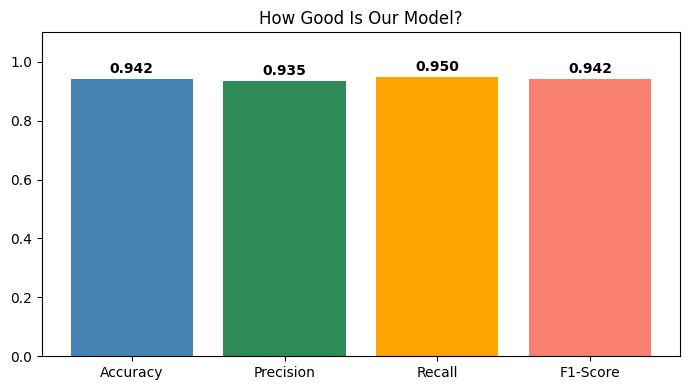

In [31]:
# Visual comparison
fig, ax = plt.subplots(figsize=(7, 4))
names, vals = ['Accuracy', 'Precision', 'Recall', 'F1-Score'], [accuracy, precision, recall, f1]
bars = ax.bar(names, vals, color=['steelblue', 'seagreen', 'orange', 'salmon'])
ax.set_ylim(0, 1.1); ax.set_title('How Good Is Our Model?')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. ROC Curve & AUC Score <a id='10'></a>

The **ROC Curve** shows how well the model separates the two classes across *all possible thresholds*.

- **AUC = 1.0** → Perfect model
- **AUC = 0.5** → Random guessing (useless)
- **AUC > 0.9** → Excellent

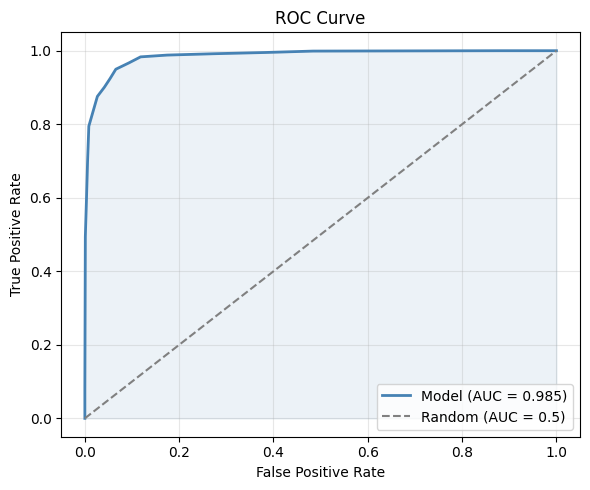

AUC: 0.9854


In [34]:
# 10. ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, prediction_proba)
auc = roc_auc_score(y_test, prediction_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f'Model (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"AUC: {auc:.4f}")

## Quick Summary

| Step | What We Did |
|------|------------|
| Load Data | Read 70,000 patient records from CSV |
| Explore | Checked for missing data, looked at distributions |
| Prepare | Separated features (X) from target (y) |
| Split | 80% training, 20% testing |
| Train | Decision Tree with max_depth=5 |
| Evaluate | Accuracy, Precision, Recall, F1, ROC-AUC |

**Result:** Our simple Decision Tree achieved ~94% accuracy and ~0.98 AUC — quite strong for a first model!

---

## 11. Assignment <a id='11'></a>

**Dataset:** [Obesity Prediction Dataset](https://www.kaggle.com/datasets/adeniranstephen/obesity-prediction-dataset) — Kaggle, February 2025

**File:** `obesity_prediction.csv` (~2,111 records, 17 columns)

**Features:** `Gender`, `Age`, `Height`, `Weight`, `family_history_with_overweight`, `FAVC` (high caloric food), `FCVC` (vegetable consumption), `NCP` (main meals), `CAEC` (food between meals), `SMOKE`, `CH2O` (water intake), `SCC` (calorie monitoring), `FAF` (physical activity), `TUE` (technology use), `CALC` (alcohol), `MTRANS` (transportation)

**Target:** `NObeyesdad` — Obesity level (7 classes)

---

### Question 1: Find the Best Tree Depth
Test `max_depth` values of 2, 3, 4, 5, 6, 7 on the Obesity dataset. Report accuracy for each and identify the optimal depth.

### Question 2: Calculate All Metrics
Using the best depth from Q1, compute Accuracy, Precision (weighted), Recall (weighted), and F1-Score (weighted). Display the classification report.

### Question 3: Feature Importance
Extract and plot the top 10 most important features from the best Decision Tree. Which lifestyle factors matter most for predicting obesity?

### Question 4: Confusion Matrix Analysis
Plot the confusion matrix (7×7) for the best model. Which obesity classes are most often confused with each other?

---
*Md. Samiul Islam, Instructor, Skill Morph Research Lab*

In [ ]:
# Assignment Starter Code — Obesity Prediction Dataset (Kaggle, Feb 2025)
# Download: https://www.kaggle.com/datasets/adeniranstephen/obesity-prediction-dataset
# Upload to Google Drive and update the path below.

# obesity_data = pd.read_csv('/content/drive/MyDrive/datasets/obesity_prediction.csv')
# obesity_data.head()

# YOUR CODE HERE